In [1]:
from pathlib import Path
from warnings import filterwarnings

# Silence some expected warnings
filterwarnings("ignore")

import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import MACCSkeys, Draw, rdFingerprintGenerator
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn import metrics
import seaborn as sns

# Neural network specific libraries
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import ModelCheckpoint

%matplotlib inline

I0000 00:00:1775476907.782208 1193972 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775476907.786411 1193972 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775476910.684394 1193972 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775476930.202054 1193972 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONE

In [2]:
# Set path to this notebook
HERE = Path(_dh[-1])
DATA = HERE / "kinase.csv"

In [3]:
# Load data
df = pd.read_csv(DATA, index_col=0)
df = df.reset_index(drop=True)

In [4]:
# Check the dimension and missing value of the data
print("Shape of dataframe : ", df.shape)
df.info()

Shape of dataframe :  (179827, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 179827 entries, 0 to 179826
Data columns (total 5 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   molecule_chembl_id  179827 non-null  object 
 1   standard_value      179827 non-null  float64
 2   standard_units      179827 non-null  object 
 3   target_chembl_id    179827 non-null  object 
 4   smiles              179827 non-null  object 
dtypes: float64(1), object(4)
memory usage: 6.9+ MB


In [5]:
# Look at head
df.head()
# NBVAL_CHECK_OUTPUT

,molecule_chembl_id,standard_value,standard_units,target_chembl_id,smiles
0,CHEMBL13462,4000.0,nM,CHEMBL1862,CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@...
1,CHEMBL13462,16000.0,nM,CHEMBL1862,CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@...
2,CHEMBL13462,800.0,nM,CHEMBL267,CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@...
3,CHEMBL13462,9000.0,nM,CHEMBL267,CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@...
4,CHEMBL13462,1700.0,nM,CHEMBL267,CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@...


In [6]:
# Keep necessary columns in needed format and save as csv
chembl_df = df[["smiles", "standard_value"]].dropna()
chembl_df = chembl_df[chembl_df["standard_value"] > 0].reset_index(drop=True)
smiles = []
pIC50 = []
for row in chembl_df.itertuples():
    smiles.append(row.smiles)
    pIC50.append(-np.log10(row.standard_value * 1e-9))  
chembl_df = pd.DataFrame({"smiles": smiles, "pIC50": pIC50})
chembl_df.to_csv(HERE / "chembl_kinase.csv", index=False)
print(f"Rows after cleaning: {len(chembl_df)}, NaN pIC50: {chembl_df['pIC50'].isna().sum()}")
chembl_df.head()
# NBVAL_CHECK_OUTPUT

Rows after cleaning: 179154, NaN pIC50: 0


,smiles,pIC50
0,CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@...,5.397940
1,CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@...,4.795880
2,CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@...,6.096910
3,CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@...,5.045757
4,CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@...,5.769551


In [7]:
# Proposal 3: sample a subset for faster prototyping (comment out to use full dataset)
#chembl_df = chembl_df.sample(n=10000, random_state=42).reset_index(drop=True)

In [8]:
def smiles_to_fp(smiles, method="maccs", n_bits=2048):
    """
    Encode a molecule from a SMILES string into a fingerprint.

    Parameters
    ----------
    smiles : str
        The SMILES string defining the molecule.

    method : str
        The type of fingerprint to use. Default is MACCS keys.

    n_bits : int
        The length of the fingerprint.

    Returns
    -------
    array
        The fingerprint array.
    """

    # Convert smiles to RDKit mol object
    mol = Chem.MolFromSmiles(smiles)

    if method == "maccs":
        return np.array(MACCSkeys.GenMACCSKeys(mol))
    if method == "morgan2":
        fpg = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=n_bits)
        return np.array(fpg.GetCountFingerprint(mol))
    if method == "morgan3":
        fpg = rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=n_bits)
        return np.array(fpg.GetCountFingerprint(mol))
    else:
        print(f"Warning: Wrong method specified: {method}." " Default will be used instead.")
        return np.array(MACCSkeys.GenMACCSKeys(mol))

In [9]:
chembl_df["fingerprints_df"] = chembl_df["smiles"].apply(smiles_to_fp)

# Look at head
print("Shape of dataframe:", chembl_df.shape)
chembl_df.head(3)
# NBVAL_CHECK_OUTPUT

Shape of dataframe: (179154, 3)


,smiles,pIC50,fingerprints_df
0,CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@...,5.39794,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@...,4.79588,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,CC(=O)N[C@@H](Cc1ccc(OP(=O)(O)O)cc1)C(=O)N[C@@...,6.09691,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [10]:
#save the dataframe with fingerprints as csv
chembl_df.to_csv(HERE / "chembl_kinase_fps.csv", index=False)

In [11]:
# Split the data into training and test set x=features, y= target data
x_train, x_test, y_train, y_test = train_test_split(
    chembl_df["fingerprints_df"], chembl_df[["pIC50"]], test_size=0.3, random_state=42
)

# Print the shape of training and testing data
print("Shape of training data:", x_train.shape)
print("Shape of test data:", x_test.shape)

# Save training and test sets as separate CSV files
train_df = pd.DataFrame({"fingerprints_df": x_train.values, "pIC50": y_train.values.flatten()})
test_df = pd.DataFrame({"fingerprints_df": x_test.values, "pIC50": y_test.values.flatten()})
train_df.to_csv(HERE / "train_set.csv", index=False)
test_df.to_csv(HERE / "test_set.csv", index=False)
print("Saved train_set.csv and test_set.csv")
# NBVAL_CHECK_OUTPUT

Shape of training data: (125407,)
Shape of test data: (53747,)
Saved train_set.csv and test_set.csv


Define neural network¶

A keras model is defined by specifying the number of neurons in the hidden layers and the activation function as arguments. For our purpose, we define a model with two hidden layers. We use ReLU in the hidden layers and a linear function on the output layer, since the aim is to predict pIC50 values. Finally, we compile the model using the mean squared error as a loss argument and adam as an optimizer.

In [12]:
def neural_network_model(hidden1, hidden2):
    """
    Creating a neural network from two hidden layers
    using ReLU as activation function in the two hidden layers
    and a linear activation in the output layer.

    Parameters
    ----------
    hidden1 : int
        Number of neurons in first hidden layer.

    hidden2: int
        Number of neurons in second hidden layer.

    Returns
    -------
    model
        Fully connected neural network model with two hidden layers.
    """

    model = Sequential()
    # First hidden layer
    model.add(Dense(hidden1, activation="relu", name="layer1"))
    # Second hidden layer
    model.add(Dense(hidden2, activation="relu", name="layer2"))
    # Output layer
    model.add(Dense(1, activation="linear", name="layer3"))

    # Compile model
    model.compile(loss="mean_squared_error", optimizer="adam", metrics=["mse", "mae"])
    return model

Train the model¶

We try different mini-batch sizes and plot the respective losses.

In [13]:
# Neural network parameters
batch_sizes = [16, 32, 64]
nb_epoch = 50  # proposal 2: reduced from 50 for faster prototyping
layer1_size = 64
layer2_size = 32

E0000 00:00:1775477168.736645 1193972 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1775477168.766307 1194349 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
E0000 00:00:1775477168.818988 1193972 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1775477168.819031 1194349 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1775477168.825312 1193972 gpu_device.cc:2365] Cannot dlopen some GPU l

Batch 16: first loss = 1.5215
Batch 32: first loss = 1.5367
Batch 64: first loss = 1.7549


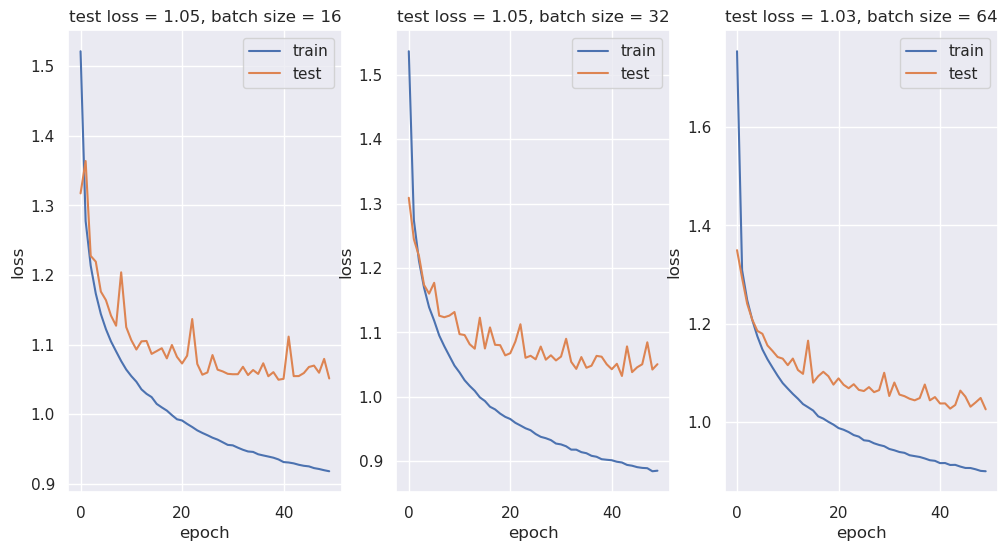

In [14]:
# Pre-convert training and test arrays once (proposal 1: avoid redundant conversion in loop)
X_train = np.array(list(x_train)).astype(float)
X_test = np.array(list(x_test)).astype(float)

# Plot
fig = plt.figure(figsize=(12, 6))
sns.set_theme(color_codes=True)
for index, batch in enumerate(batch_sizes):
    fig.add_subplot(1, len(batch_sizes), index + 1)
    model = neural_network_model(layer1_size, layer2_size)

    # Fit model on x_train, y_train data
    history = model.fit(
        X_train,
        y_train.values,
        batch_size=batch,
        validation_data=(X_test, y_test.values),
        verbose=0,
        epochs=nb_epoch,
    )
    first_loss = history.history["loss"][0]
    print(f"Batch {batch}: first loss = {first_loss:.4f}")  # NaN here means bad input data
    plt.plot(history.history["loss"], label="train")
    plt.plot(history.history["val_loss"], label="test")
    plt.legend(["train", "test"], loc="upper right")
    plt.ylabel("loss")
    plt.xlabel("epoch")
    plt.title(
        f"test loss = {history.history['val_loss'][nb_epoch-1]:.2f}, " f"batch size = {batch}"
    )
plt.show()

Now, we train the model with a batch size of 16 this time (because as seen from the figure above, it has the lowest test loss) and we save the weights that give the best perfomance in the file best_weights.hdf5.

In [15]:
# Save the trained model
filepath = HERE / "best_weights.weights.h5"
checkpoint = ModelCheckpoint(
    str(filepath),
    monitor="loss",
    verbose=0,
    save_best_only=True,
    mode="min",
    save_weights_only=True,
)
callbacks_list = [checkpoint]

# Fit the model
model.fit(
    X_train,
    y_train.values,
    epochs=nb_epoch,
    batch_size=16,
    callbacks=callbacks_list,
    verbose=0,
)

In [16]:
# Evalute the models performance
print(f"Evaluate the model on the test data")
scores = model.evaluate(X_test, y_test.values, verbose=0)
print(f" loss: {scores[0]:.2f}")
print(f" mse (same as loss): {scores[1]:.2f}") #mean squared error
print(f" mae: {scores[2]:.2f}") #mean absolute error

Evaluate the model on the test data
 loss: 1.04
 mse (same as loss): 1.04
 mae: 0.80


### Predictions on test set

In [17]:
# Predict pIC50 values on x_test data
y_pred = model.predict(X_test)

# Print 5 first pIC50 predicted values
first_5_prediction = [print(f"{value[0]:.2f}") for value in y_pred[0:5]]

1680/1680 ━━━━━━━━━━━━━━━━━━━━ 1s 363us/step
6.84
6.74
7.37
7.46
6.52


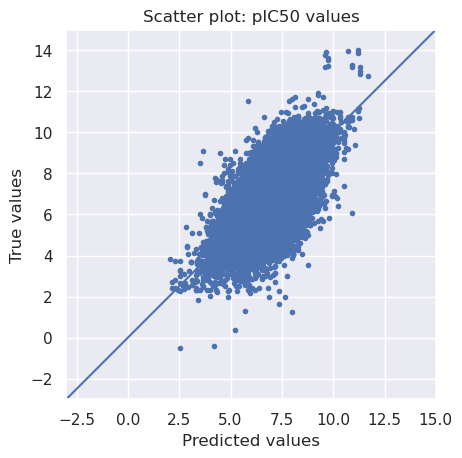

In [18]:
# Scatter plot
limits = -3, 15
fig, ax = plt.subplots()
ax.scatter(y_pred, y_test, marker=".")
lin = np.linspace(*limits, 100)
ax.plot(lin, lin)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Predicted values")
ax.set_ylabel("True values")
ax.set_title("Scatter plot: pIC50 values")
ax.set_xlim(limits)
ax.set_ylim(limits)
plt.show()

### Go on external data
thought it might be good to have inhibitors of same kinase but do not know of what kinase the training data is

In [19]:
# Load external/unlabeled data set (mouse pKi TSV, SMILES column only)
external_data = pd.read_csv(HERE / "mouse_PKI_inactive.tsv", sep="\t", index_col=0)
external_data = external_data.reset_index(drop=True)
external_data = external_data[["nonstereo_aromatic_smiles"]].rename(columns={"nonstereo_aromatic_smiles": "smiles"})
# If the source column has a different name, update the key below:
# external_data = external_data[["Smiles"]].rename(columns={"Smiles": "smiles"})
print("Shape:", external_data.shape)
external_data.head()
# NBVAL_CHECK_OUTPUT

Shape: (522, 1)


,smiles
0,CCCCCCCCCC(=O)Nc1ccc(S(=O)(=O)Nc2nncs2)cc1
1,CCCCCCCCCC(=O)Nc1ccc(S(=O)(=O)Nc2nnc(C)s2)cc1
2,CCCCCCCCCC(=O)Nc1ccc(S(=O)(=O)Nc2nnc(C(C)(C)C)...
3,CCCCCCCCCC(=O)Nc1ccc(S(=O)(=O)Nc2nnc(CO)s2)cc1
4,CCCCCCCCCCCCCCCCCCc1ccc(S(=O)(=O)Nc2nncs2)cc1


In [20]:
# Convert SMILES strings to MACCS fingerprints
external_data["fingerprints_df"] = external_data["smiles"].apply(smiles_to_fp)

# Look at head
print("Shape of dataframe : ", external_data.shape)
external_data.head(3)
# NBVAL_CHECK_OUTPUT

Shape of dataframe :  (522, 2)


,smiles,fingerprints_df
0,CCCCCCCCCC(=O)Nc1ccc(S(=O)(=O)Nc2nncs2)cc1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,CCCCCCCCCC(=O)Nc1ccc(S(=O)(=O)Nc2nnc(C)s2)cc1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,CCCCCCCCCC(=O)Nc1ccc(S(=O)(=O)Nc2nnc(C(C)(C)C)...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [21]:
# Rebuild model architecture and load the saved best weights
model = neural_network_model(layer1_size, layer2_size)
model.build(input_shape=(None, X_train.shape[1]))
model.load_weights(str(HERE / "best_weights.weights.h5"))

In [22]:
# Prediction on external/unlabeled data
predictions = model.predict(
    np.array(list((external_data["fingerprints_df"]))).astype(float), callbacks=callbacks_list
)

predicted_pIC50 = pd.DataFrame(predictions, columns=["predicted_pIC50"])
predicted_pIC50_df = external_data.join(predicted_pIC50)

predicted_pIC50_df.head(3)

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


,smiles,fingerprints_df,predicted_pIC50
0,CCCCCCCCCC(=O)Nc1ccc(S(=O)(=O)Nc2nncs2)cc1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",5.921099
1,CCCCCCCCCC(=O)Nc1ccc(S(=O)(=O)Nc2nnc(C)s2)cc1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",6.210538
2,CCCCCCCCCC(=O)Nc1ccc(S(=O)(=O)Nc2nnc(C(C)(C)C)...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",5.955695


In [23]:
# Save the predicted values in a csv file in the data folder
predicted_pIC50_df.to_csv(HERE / "predicted_pIC50_df.csv")

In [24]:
# Select top 3 drugs
predicted_pIC50_df = pd.read_csv(HERE / "predicted_pIC50_df.csv", index_col=0)
top3_drug = predicted_pIC50_df.nlargest(3, "predicted_pIC50")
top3_drug

,smiles,fingerprints_df,predicted_pIC50
439,CC(O)CNC(=O)c1cnccc1Nc1cc(-c2cc(Cl)ccc2F)ncc1Br,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...,9.253756
456,CC(O)CNC(=O)c1cnccc1Nc1cc(-c2cc(Cl)ccc2F)ncc1C...,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1...,9.142265
440,CC(O)CNC(=O)c1cnccc1Nc1cc(-c2cc(Cl)ccc2F)ncc1C...,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...,8.731945


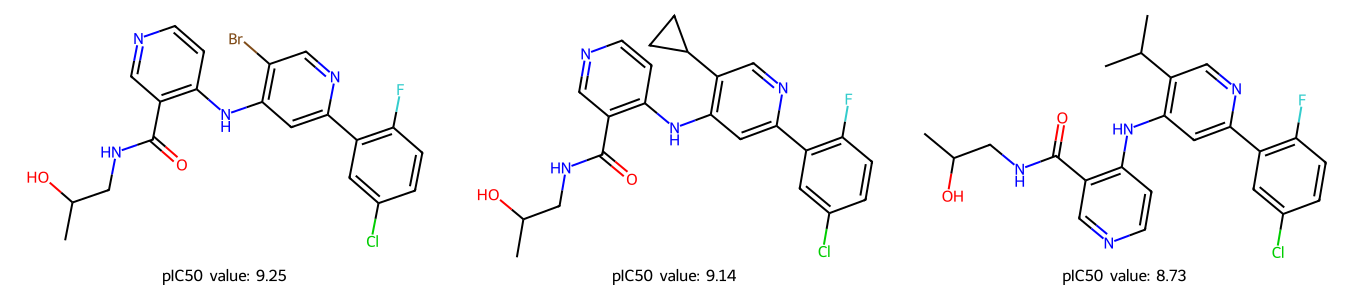

In [25]:
# Draw the drug molecules
highest_pIC50 = predicted_pIC50_df["smiles"][top3_drug.index]

mols_EGFR = [Chem.MolFromSmiles(smile) for smile in highest_pIC50]
pIC50_EGFR = top3_drug["predicted_pIC50"].tolist()
pIC50_values = [(f"pIC50 value: {value:.2f}") for value in pIC50_EGFR]

Draw.MolsToGridImage(mols_EGFR, molsPerRow=3, subImgSize=(450, 300), legends=pIC50_values)